# 01B — Exploration Dataset 2 : Industrial Equipment Monitoring

**Objectif** : Analyser la contribution individuelle de chaque variable (`temperature`, `pressure`, `vibration`, `humidity`) sur le label `faulty`.

**Visualisation principale** : sorted scatter — chaque feature est triée par valeur croissante, les points sont colorés par état (`faulty=0` vert / `faulty=1` rouge). Révèle dans quelle plage de valeurs les équipements défectueux se concentrent.

- **Dataset** : `data/raw/equipment_monitoring/Industrial_Equipment_Monitoring_Dataset/equipment_anomaly_data.csv`
- **Label** : `faulty` (0 = normal, 1 = défectueux, ~10% de taux de défaut)
- **Domaines CL** : Pump → Turbine → Compressor

In [9]:
import pathlib
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sys.path.insert(0, "..")
from src.evaluation.eda_plots import (
    COLORS_LABEL,
    FIGURE_DPI,
    FIGURE_FONT_SIZE,
    plot_boxplots_by_label,
    plot_kde_by_label,
    plot_sorted_scatter_by_label,
)

DATA_PATH = pathlib.Path(
    "../data/raw/equipment_monitoring/"
    "Industrial_Equipment_Monitoring_Dataset/equipment_anomaly_data.csv"
)
FIGURES_DIR = pathlib.Path("figures/eda/equipment_monitoring/01B")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

FEATURE_COLS = ["temperature", "pressure", "vibration", "humidity"]
DOMAIN_ORDER = ["Pump", "Turbine", "Compressor"]

sns.set_theme(style="whitegrid", palette="muted")
%matplotlib inline
print("Setup OK")

Setup OK


In [10]:
df = pd.read_csv(DATA_PATH)

print(f"Shape : {df.shape}")
print(f"\nColonnes : {list(df.columns)}")
print(f"\nValeurs manquantes :\n{df.isnull().sum()}")
print(f"\nTaux de défaut global : {df['faulty'].mean():.3f} ({int(df['faulty'].sum())}/{len(df)})")
print(f"\nDistribution par équipement :\n{df['equipment'].value_counts()}")
df[FEATURE_COLS + ["faulty"]].describe().round(3)

Shape : (7672, 7)

Colonnes : ['temperature', 'pressure', 'vibration', 'humidity', 'equipment', 'location', 'faulty']

Valeurs manquantes :
temperature    0
pressure       0
vibration      0
humidity       0
equipment      0
location       0
faulty         0
dtype: int64

Taux de défaut global : 0.100 (767/7672)

Distribution par équipement :
equipment
Compressor    2573
Turbine       2565
Pump          2534
Name: count, dtype: int64


,temperature,pressure,vibration,humidity,faulty
count,7672.000,7672.000,7672.000,7672.000,7672.0
mean,70.922,35.738,1.612,50.017,0.1
std,16.200,10.382,0.729,11.841,0.3
min,10.269,3.621,-0.428,10.215,0.0
25%,62.777,29.486,1.171,42.613,0.0
50%,70.157,35.228,1.533,50.025,0.0
75%,77.568,41.160,1.925,57.341,0.0
max,149.690,79.888,4.991,89.985,1.0


---
## Section 1 — Distribution du label `faulty`

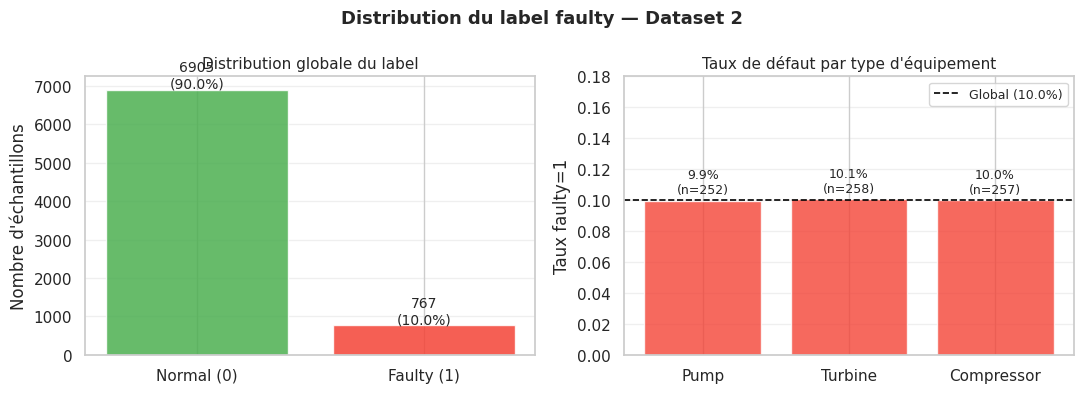

✓ Sauvegardé : figures/eda/equipment_monitoring/01B/label_distribution.png


In [11]:
fault_by_eq = df.groupby("equipment")["faulty"].agg(["mean", "sum", "count"]).rename(
    columns={"mean": "taux_défaut", "sum": "n_faulty", "count": "n_total"}
).reindex(DOMAIN_ORDER)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Global
counts = df["faulty"].value_counts().sort_index()
axes[0].bar(
    ["Normal (0)", "Faulty (1)"],
    counts.values,
    color=[COLORS_LABEL[0], COLORS_LABEL[1]],
    alpha=0.85,
    edgecolor="white",
)
for i, count in enumerate(counts.values):
    axes[0].text(i, count + 50, f"{count}\n({count/len(df):.1%})", ha="center", fontsize=10)
axes[0].set_title("Distribution globale du label", fontsize=FIGURE_FONT_SIZE)
axes[0].set_ylabel("Nombre d'échantillons")
axes[0].grid(True, axis="y", alpha=0.3)

# Par équipement
global_rate = df["faulty"].mean()
bars = axes[1].bar(
    DOMAIN_ORDER,
    fault_by_eq["taux_défaut"],
    color=COLORS_LABEL[1],
    alpha=0.8,
    edgecolor="white",
)
for bar, (_, row) in zip(bars, fault_by_eq.iterrows()):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.003,
        f"{row['taux_défaut']:.1%}\n(n={int(row['n_faulty'])})",
        ha="center", va="bottom", fontsize=9,
    )
axes[1].axhline(global_rate, color="black", linestyle="--", linewidth=1.2,
                label=f"Global ({global_rate:.1%})")
axes[1].set_title("Taux de défaut par type d'équipement", fontsize=FIGURE_FONT_SIZE)
axes[1].set_ylabel("Taux faulty=1")
axes[1].set_ylim(0, 0.18)
axes[1].legend(fontsize=9)
axes[1].grid(True, axis="y", alpha=0.3)

fig.suptitle("Distribution du label faulty — Dataset 2", fontsize=FIGURE_FONT_SIZE + 2, fontweight="bold")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "label_distribution.png", dpi=FIGURE_DPI, bbox_inches="tight")
plt.show()
print(f"✓ Sauvegardé : {FIGURES_DIR / 'label_distribution.png'}")

---
## Section 2 — Sorted scatter : valeurs triées colorées par `faulty` (dataset complet)

Pour chaque variable (**4 figures séparées**) :
- **X** = rang dans l'ordre croissant des valeurs (0 → N-1)
- **Y** = valeur de la feature
- **Couleur** = label `faulty` (vert = normal, rouge = défectueux)

Si les points rouges se regroupent aux extrémités, la variable a un fort pouvoir discriminant. Si les rouges sont dispersés uniformément le long de la courbe, la variable discrimine mal seule.

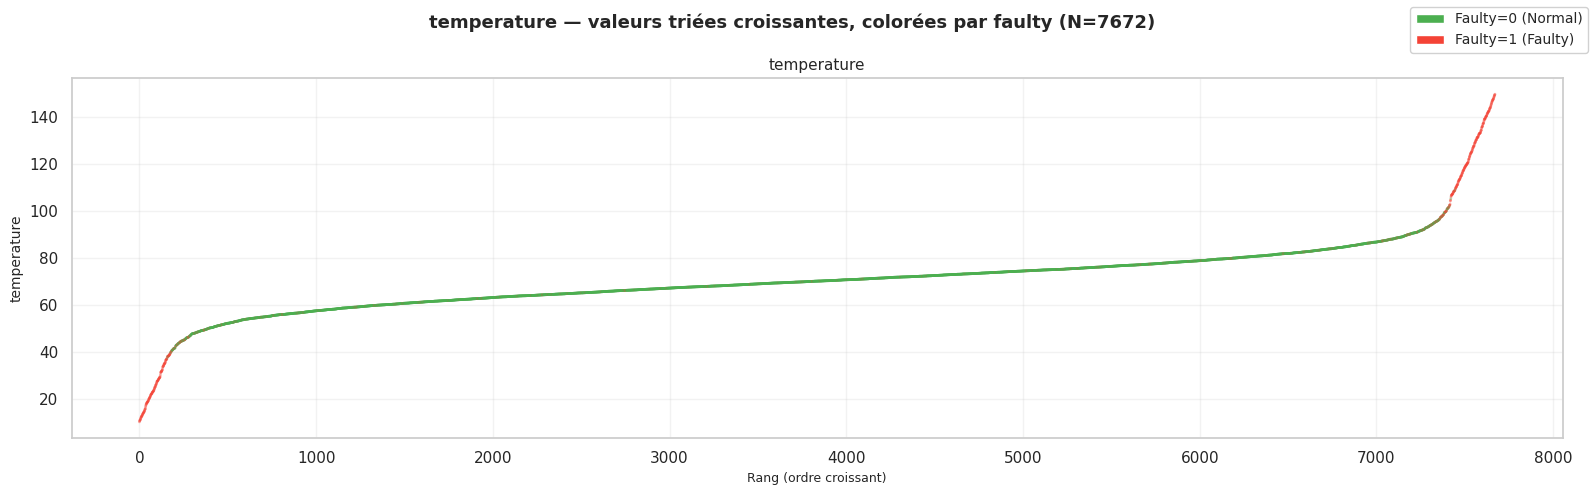

✓ temperature → figures/eda/equipment_monitoring/01B/sorted_scatter_temperature.png


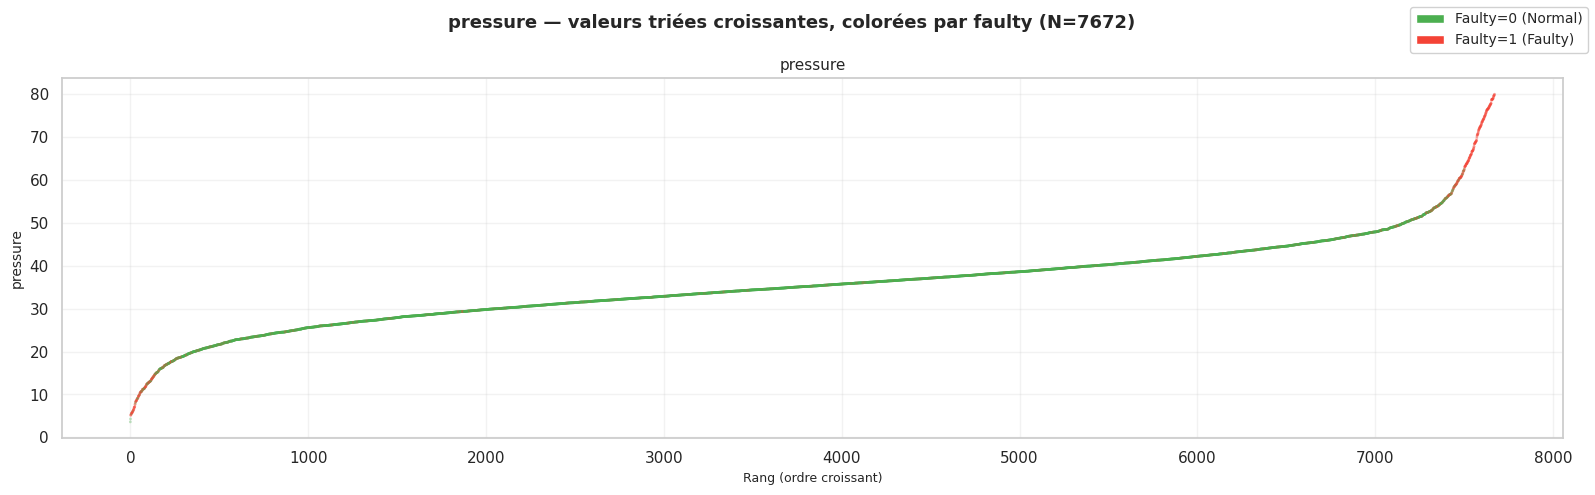

✓ pressure → figures/eda/equipment_monitoring/01B/sorted_scatter_pressure.png


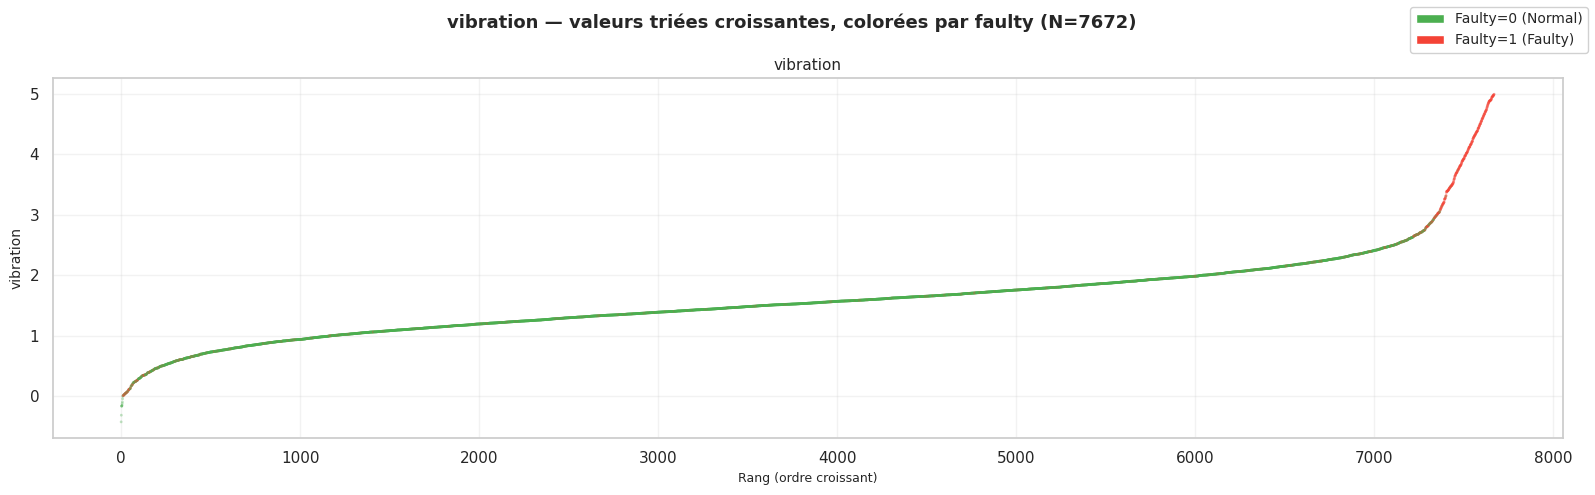

✓ vibration → figures/eda/equipment_monitoring/01B/sorted_scatter_vibration.png


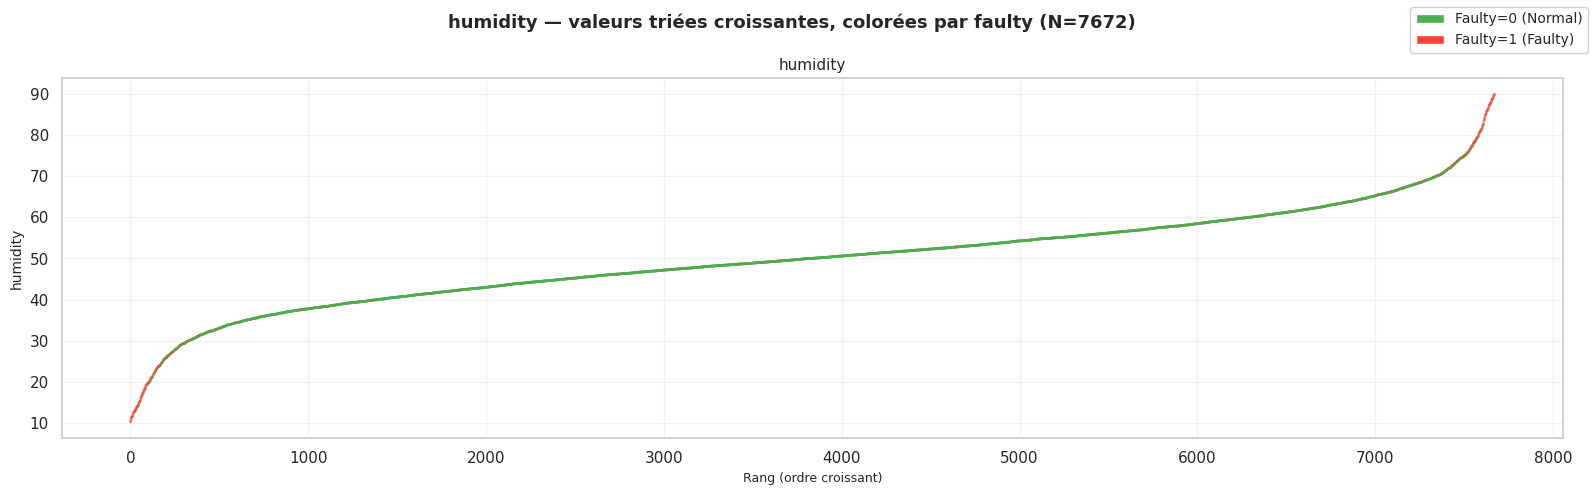

✓ humidity → figures/eda/equipment_monitoring/01B/sorted_scatter_humidity.png


In [12]:
for feat in FEATURE_COLS:
    fig = plot_sorted_scatter_by_label(
        df,
        feature_cols=[feat],
        label_col="faulty",
        label_name="Faulty",
        alpha=0.35,
        s=4,
        title=f"{feat} — valeurs triées croissantes, colorées par faulty (N={len(df)})",
        save_path=FIGURES_DIR / f"sorted_scatter_{feat}.png",
    )
    plt.show()
    print(f"✓ {feat} → {FIGURES_DIR / f'sorted_scatter_{feat}.png'}")

---
## Section 3 — Sorted scatter par type d'équipement

Même visualisation décomposée par domaine CL — **4 figures séparées** (une par variable),
chaque figure ayant 3 subplots côte à côte (Pump / Turbine / Compressor).
Permet de voir si la séparation normal/faulty varie entre domaines.

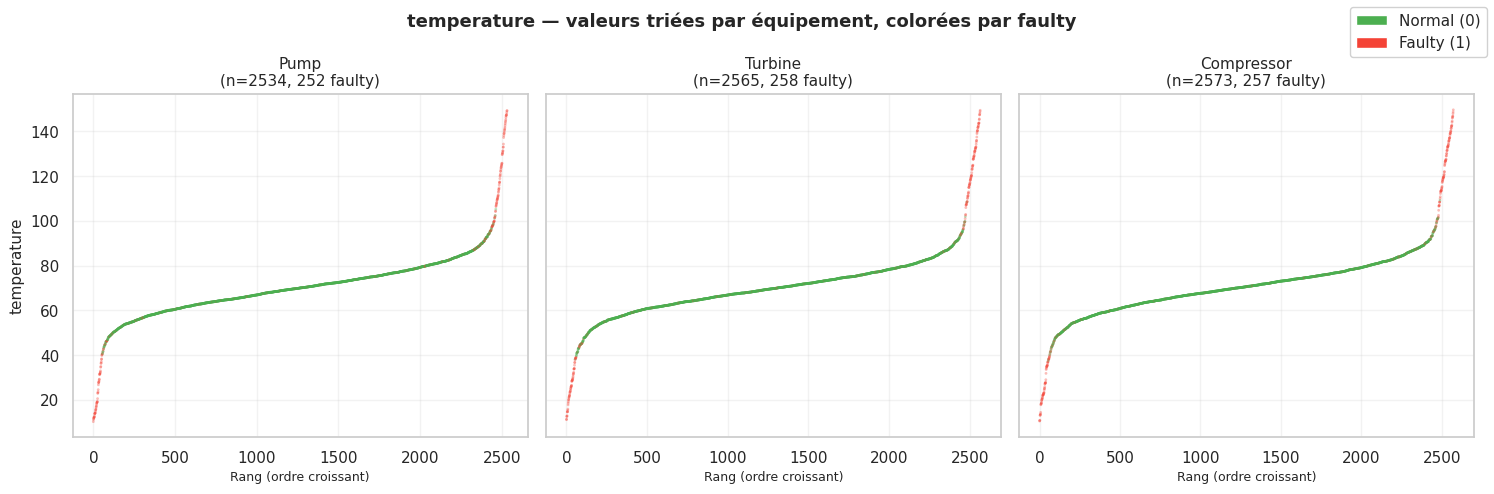

✓ temperature → figures/eda/equipment_monitoring/01B/sorted_scatter_temperature_by_equipment.png


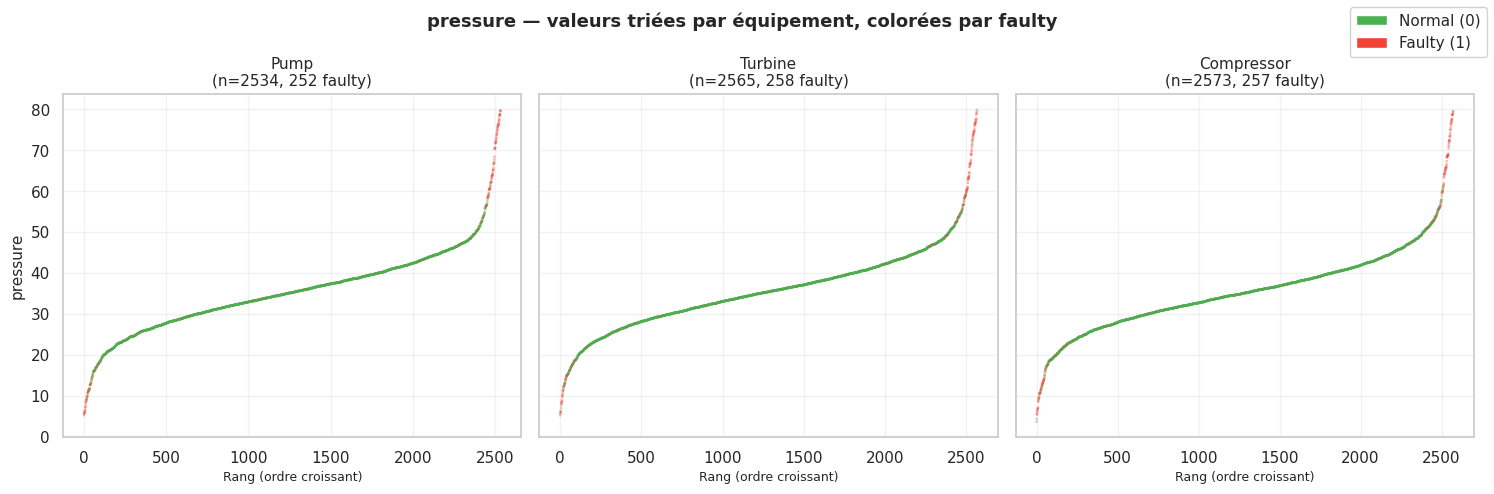

✓ pressure → figures/eda/equipment_monitoring/01B/sorted_scatter_pressure_by_equipment.png


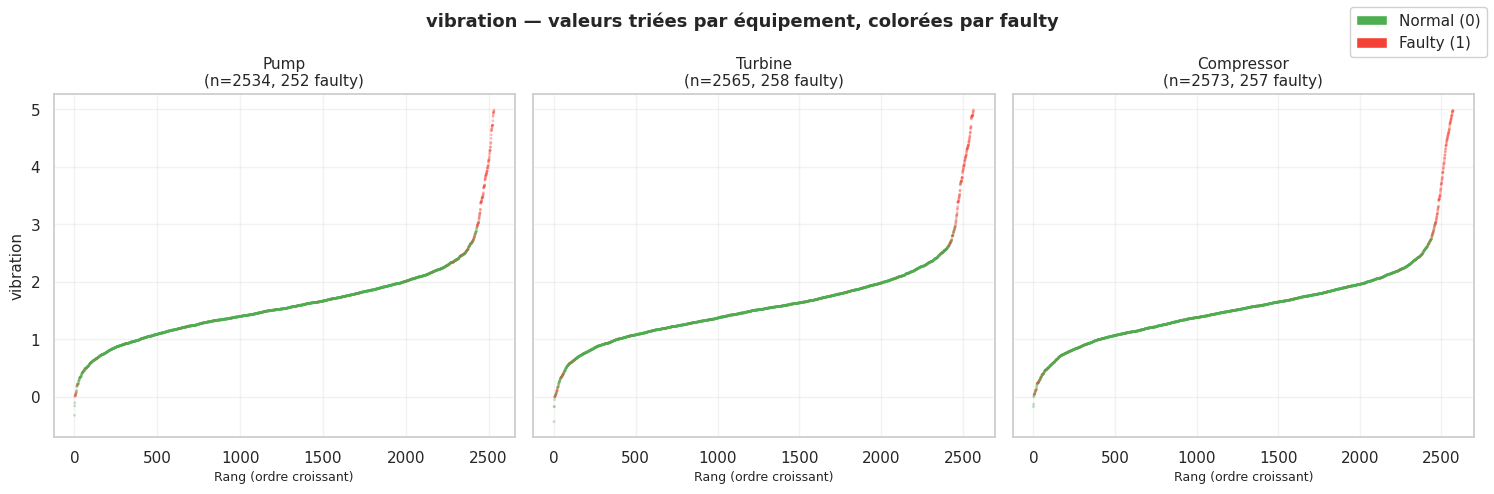

✓ vibration → figures/eda/equipment_monitoring/01B/sorted_scatter_vibration_by_equipment.png


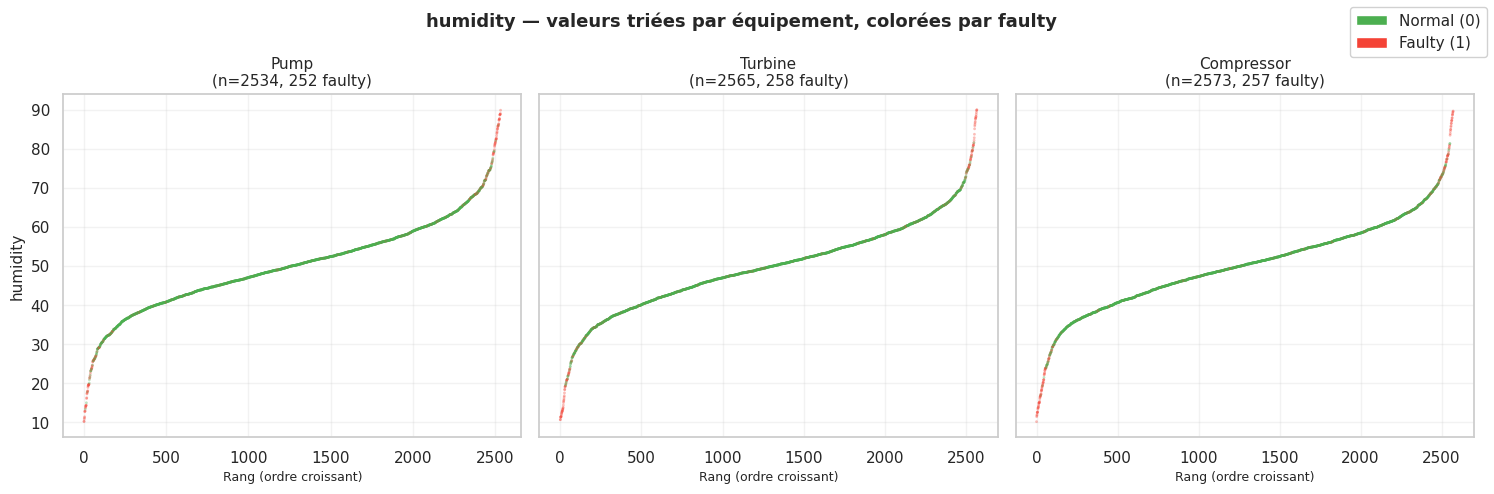

✓ humidity → figures/eda/equipment_monitoring/01B/sorted_scatter_humidity_by_equipment.png


In [13]:
from matplotlib.patches import Patch

legend_handles = [
    Patch(facecolor=COLORS_LABEL[0], label="Normal (0)"),
    Patch(facecolor=COLORS_LABEL[1], label="Faulty (1)"),
]

for feat in FEATURE_COLS:
    fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

    for ax, eq in zip(axes, DOMAIN_ORDER):
        df_eq = df[df["equipment"] == eq].reset_index(drop=True)
        n_faulty = int(df_eq["faulty"].sum())
        n_total = len(df_eq)

        valid = df_eq[[feat, "faulty"]].dropna()
        sorted_idx = valid[feat].argsort().values
        sorted_vals = valid[feat].values[sorted_idx]
        sorted_labels = valid["faulty"].values[sorted_idx].astype(int)
        colors = [COLORS_LABEL.get(v, "#999999") for v in sorted_labels]

        ax.scatter(
            range(len(sorted_vals)),
            sorted_vals,
            c=colors,
            alpha=0.35,
            s=4,
            linewidths=0,
        )
        ax.set_title(f"{eq}\n(n={n_total}, {n_faulty} faulty)", fontsize=FIGURE_FONT_SIZE)
        ax.set_xlabel("Rang (ordre croissant)", fontsize=FIGURE_FONT_SIZE - 2)
        ax.grid(True, alpha=0.25)

    axes[0].set_ylabel(feat, fontsize=FIGURE_FONT_SIZE)

    fig.legend(
        handles=legend_handles,
        loc="upper right",
        fontsize=FIGURE_FONT_SIZE,
        framealpha=0.9,
    )
    fig.suptitle(
        f"{feat} — valeurs triées par équipement, colorées par faulty",
        fontsize=FIGURE_FONT_SIZE + 2,
        fontweight="bold",
    )
    fig.tight_layout()
    save_path = FIGURES_DIR / f"sorted_scatter_{feat}_by_equipment.png"
    fig.savefig(save_path, dpi=FIGURE_DPI, bbox_inches="tight")
    plt.show()
    print(f"✓ {feat} → {save_path}")

---
## Section 4 — Compléments : KDE et boxplots

Visualisations complémentaires pour quantifier la séparation normal/faulty par feature.

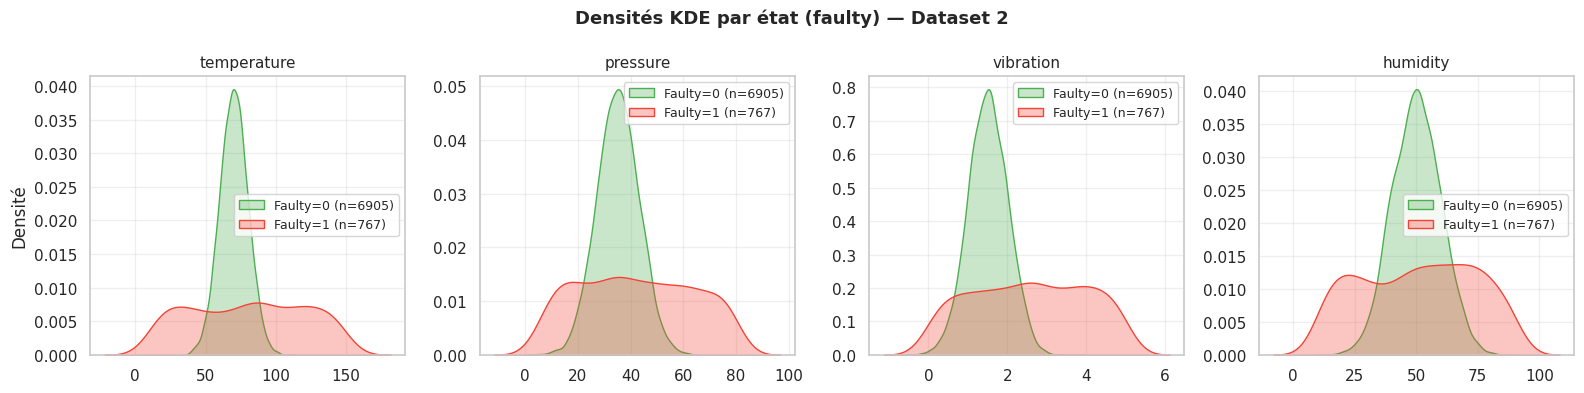

In [14]:
fig = plot_kde_by_label(
    df,
    feature_cols=FEATURE_COLS,
    label_col="faulty",
    label_name="Faulty",
    title="Densités KDE par état (faulty) — Dataset 2",
)
fig.savefig(FIGURES_DIR / "kde_by_faulty.png", dpi=FIGURE_DPI, bbox_inches="tight")
plt.show()

/home/leonard/Documents/ENAC/cl-embedded/notebooks/../src/evaluation/eda_plots.py:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/home/leonard/Documents/ENAC/cl-embedded/notebooks/../src/evaluation/eda_plots.py:91: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(label_labels, fontsize=FIGURE_FONT_SIZE - 1)
/home/leonard/Documents/ENAC/cl-embedded/notebooks/../src/evaluation/eda_plots.py:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/home/leonard/Documents/ENAC/cl-embedded/notebooks/../src/evaluation/eda_plots.py:91: UserWarning: set_ticklabels() should only be used with a fixed num

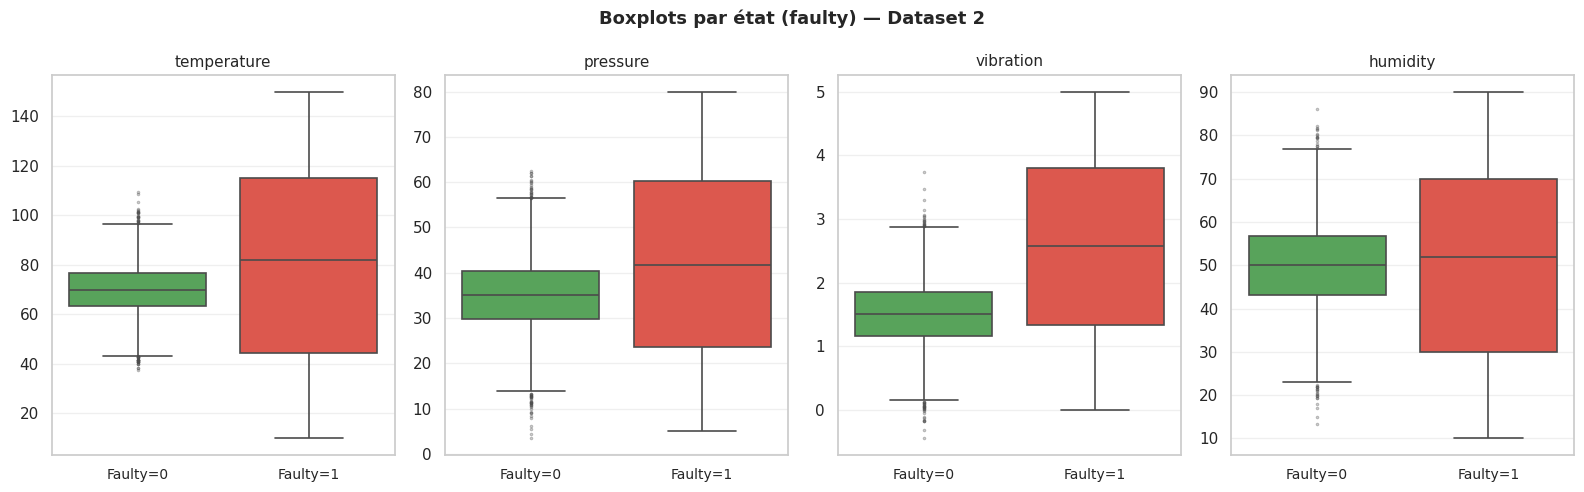

In [15]:
fig = plot_boxplots_by_label(
    df,
    feature_cols=FEATURE_COLS,
    label_col="faulty",
    label_name="Faulty",
    title="Boxplots par état (faulty) — Dataset 2",
)
fig.savefig(FIGURES_DIR / "boxplots_by_faulty.png", dpi=FIGURE_DPI, bbox_inches="tight")
plt.show()

---
## Section 5 — Statistiques de séparation par feature

Différence de moyenne et ratio des écarts-types entre normal et faulty, pour quantifier le pouvoir discriminant de chaque variable.

In [16]:
stats_normal = df[df["faulty"] == 0][FEATURE_COLS].agg(["mean", "std"])
stats_faulty = df[df["faulty"] == 1][FEATURE_COLS].agg(["mean", "std"])

sep = pd.DataFrame({
    "mean_normal": stats_normal.loc["mean"],
    "mean_faulty": stats_faulty.loc["mean"],
    "std_normal": stats_normal.loc["std"],
    "std_faulty": stats_faulty.loc["std"],
})
sep["delta_mean"] = (sep["mean_faulty"] - sep["mean_normal"]).abs()
sep["delta_mean_pct"] = sep["delta_mean"] / sep["mean_normal"] * 100
sep["std_ratio"] = sep["std_faulty"] / sep["std_normal"]

print("Séparation normal vs faulty par feature :")
print(sep[["mean_normal", "mean_faulty", "delta_mean", "delta_mean_pct", "std_ratio"]].round(3))

Séparation normal vs faulty par feature :
             mean_normal  mean_faulty  delta_mean  delta_mean_pct  std_ratio
temperature       69.927       79.880       9.953          14.233      4.039
pressure          35.038       42.039       7.000          19.980      2.668
vibration          1.507        2.555       1.048          69.522      2.845
humidity          49.967       50.466       0.499           0.999      2.327


---
## Observations

- **Sorted scatter** : si les points rouges (faulty) se regroupent aux extrémités (valeurs très hautes ou très basses), la feature a un fort pouvoir discriminant individuel. Si les rouges sont dispersés aléatoirement le long de la courbe, la feature discrimine mal seule.
- **KDE** : le chevauchement des densités normale/faulty indique la difficulté de classification univariée.
- **Implications pour EWC/HDC** : les features avec la meilleure séparation peuvent recevoir un poids plus élevé dans les métriques d'évaluation ou les fonctions de distance (Mahalanobis, HDC encodage).
- **Scénario CL** : si la séparation varie significativement entre Pump, Turbine et Compressor (Section 3), cela justifie l'utilisation d'un scénario Domain-Incremental plutôt qu'un modèle unique.